In [5]:
from pathlib import Path
import re
import pandas as pd

# The notebook lives in notebooks/, so this path resolves to data/raw/ontario_housing.csv.
PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "ontario_housing.csv"
raw_df = pd.read_csv(DATA_PATH)

# Convert long source labels into stable, readable feature names.
def to_snake_case(column_name):
    column_name = re.sub(r"[^0-9a-zA-Z]+", "_", column_name).strip("_").lower()
    return re.sub(r"_+", "_", column_name)

df = raw_df.rename(columns=to_snake_case).copy()

# Currency values are quoted and contain commas; categorical policy fields remain strings.
for column in df.columns:
    if column not in {"municipality", "tier", "region"}:
        df[column] = pd.to_numeric(
            df[column].astype(str).str.replace(",", "", regex=False),
            errors="coerce",
        )

df = df.drop(columns=["id"], errors="ignore")
print(f"Loaded {len(df):,} municipalities and {df.shape[1]:,} columns.")
print(df[["municipality", "tier", "region", "affordable_purchase_price_of_a_detached_house"]].head())

Loaded 414 municipalities and 33 columns.
             municipality tier   region  \
0  Addington Highlands Tp   LT  Eastern   
1    Adelaide-Metcalfe Tp   LT  Western   
2    Adjala-Tosorontio Tp   LT  Central   
3     Admaston-Bromley Tp   LT  Eastern   
4                  Ajax T   LT  Central   

   affordable_purchase_price_of_a_detached_house  
0                                         260000  
1                                         481200  
2                                         539400  
3                                         407400  
4                                         535500  


In [6]:
import pandas as pd
import requests

# Ontario Data API endpoint for the housing affordability dataset.
url = "https://data.ontario.ca/api/3/action/datastore_search?resource_id=0fc0f788-ac93-45a5-a4f6-af542cd223d7&limit=10"
response = requests.get(url, timeout=30)
response.raise_for_status()
payload = response.json()

# CKAN DataStore responses keep tabular rows under result.records.
if not payload.get("success"):
    raise RuntimeError(f"Ontario Data API request failed: {payload}")

df_api = pd.DataFrame(payload["result"]["records"])
print(f"Loaded {len(df_api)} rows from the API.")
print(df_api.head(10).to_string(index=False))

Loaded 10 rows from the API.
 _id              Municipality Tier       Region Affordable purchase price of a detached house ($) Affordable purchase price of a semi-detached house ($) Affordable purchase price of a row/townhouse ($) Affordable purchase price of a condominium apartment ($) Purchase price based on income ($) Ninety per cent of average purchase price - detached ($) Ninety per cent of average purchase price - semi-detached ($) Ninety per cent of average purchase price - row/townhouse ($) Ninety per cent of average purchase price - condo apt ($) Average purchase price of a detached house ($) Average purchase price of a semi-detached house ($) Average purchase price of a row/townhouse ($) Average purchase price of a condominium apartment ($) Threshold applied for a detached house; and substitution ($) Threshold applied for a semi-detached; and substitution ($) Threshold applied for a row/townhouse; and substitution ($) Threshold applied for a condo apartment; and substitution

In [7]:
import sqlite3

DB_PATH = PROJECT_ROOT / "data" / "raw" / "housing_database.db"
TABLE_NAME = "ontario_housing"

# Write the original CSV data into SQLite.
with sqlite3.connect(DB_PATH) as connection:
    raw_df.to_sql(TABLE_NAME, connection, if_exists="replace", index=False)

# Read the table back from SQLite into a new DataFrame.
with sqlite3.connect(DB_PATH) as connection:
    df_database = pd.read_sql_query(
        f'SELECT * FROM "{TABLE_NAME}"',
        connection,
    )

print(f"Saved CSV data to: {DB_PATH}")
print(f"Loaded {len(df_database):,} rows from the SQLite table '{TABLE_NAME}'.")
print(df_database.head(10).to_string(index=False))

Saved CSV data to: c:\Users\Davisen\Documents\GitHub\CSCN8010-LinearRegressionArchitecture_Workshop\data\raw\housing_database.db
Loaded 414 rows from the SQLite table 'ontario_housing'.
 _id              Municipality Tier       Region Affordable purchase price of a detached house ($) Affordable purchase price of a semi-detached house ($) Affordable purchase price of a row/townhouse ($) Affordable purchase price of a condominium apartment ($) Purchase price based on income ($) Ninety per cent of average purchase price - detached ($) Ninety per cent of average purchase price - semi-detached ($) Ninety per cent of average purchase price - row/townhouse ($) Ninety per cent of average purchase price - condo apt ($) Average purchase price of a detached house ($) Average purchase price of a semi-detached house ($) Average purchase price of a row/townhouse ($) Average purchase price of a condominium apartment ($) Threshold applied for a detached house; and substitution ($) Threshold applied fo

Missing values in the target: 0
Target summary ($):
count       414.0
mean     378373.0
std       89550.0
min      144000.0
25%      318200.0
50%      368600.0
75%      430700.0
max      667400.0

Average affordable detached-house price by region ($):
              count      mean    median
region                                 
Central          62  457944.0  463700.0
Eastern         103  372735.0  372500.0
Northeastern    110  316146.0  303350.0
Northwestern     34  300368.0  279550.0
Western         105  427370.0  411300.0


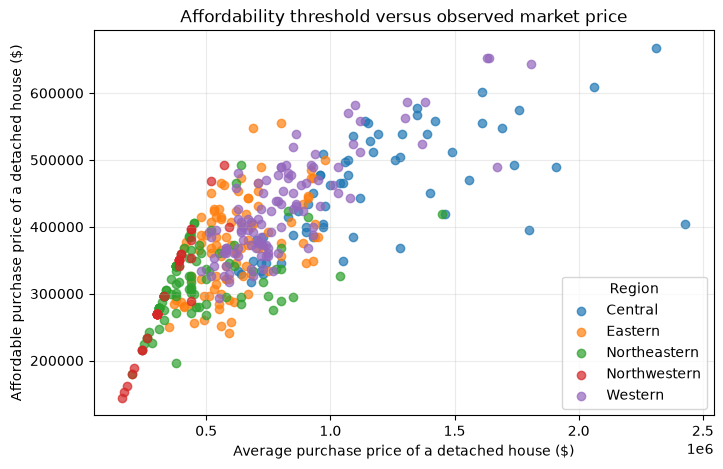

In [8]:
import matplotlib.pyplot as plt

TARGET = "affordable_purchase_price_of_a_detached_house"

print("Missing values in the target:", int(df[TARGET].isna().sum()))
print("Target summary ($):")
print(df[TARGET].describe().round(0).to_string())
print("\nAverage affordable detached-house price by region ($):")
print(df.groupby("region")[TARGET].agg(["count", "mean", "median"]).round(0).to_string())

# This relationship is substantively meaningful: affordable prices should generally rise
# with observed detached-house market prices, but it is not the target itself.
plt.figure(figsize=(8, 5))
for region, group in df.groupby("region"):
    plt.scatter(
        group["average_purchase_price_of_a_detached_house"],
        group[TARGET],
        alpha=0.7,
        label=region,
    )
plt.xlabel("Average purchase price of a detached house ($)")
plt.ylabel("Affordable purchase price of a detached house ($)")
plt.title("Affordability threshold versus observed market price")
plt.legend(title="Region")
plt.grid(alpha=0.25)
plt.show()

In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Exclude the target and the income-based price because it is an alternate calculation
# of affordability and would make the prediction task artificially circular.
feature_frame = df.dropna(subset=[TARGET]).copy()
excluded_columns = {TARGET, "purchase_price_based_on_income"}
numeric_features = [
    column
    for column in feature_frame.select_dtypes(include="number").columns
    if column not in excluded_columns and feature_frame[column].notna().any()
]
categorical_features = ["tier", "region"]
feature_columns = numeric_features + categorical_features

X = feature_frame[feature_columns]
y = feature_frame[TARGET]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_features),
        ("categorical", categorical_transformer, categorical_features),
    ]
)

print(f"Predictors: {len(numeric_features)} numeric + {len(categorical_features)} categorical")
print(f"Training rows: {len(X_train)} | Test rows: {len(X_test)}")
print("Excluded from predictors:", sorted(excluded_columns))

Predictors: 20 numeric + 2 categorical
Training rows: 331 | Test rows: 83
Excluded from predictors: ['affordable_purchase_price_of_a_detached_house', 'purchase_price_based_on_income']


In [10]:
from sklearn.linear_model import LinearRegression

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression()),
    ]
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Model fitted: ordinary least squares with scaled numeric features and one-hot regions.")

Model fitted: ordinary least squares with scaled numeric features and one-hot regions.


In [11]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

baseline_prediction = np.repeat(y_train.mean(), len(y_test))
metrics = pd.DataFrame(
    {
        "MAE ($)": [
            mean_absolute_error(y_test, baseline_prediction),
            mean_absolute_error(y_test, y_pred),
        ],
        "RMSE ($)": [
            np.sqrt(mean_squared_error(y_test, baseline_prediction)),
            np.sqrt(mean_squared_error(y_test, y_pred)),
        ],
        "R2": [
            r2_score(y_test, baseline_prediction),
            r2_score(y_test, y_pred),
        ],
    },
    index=["Mean baseline", "Linear regression"],
)
print(metrics.round({"MAE ($)": 0, "RMSE ($)": 0, "R2": 3}).to_string())
print(
    f"\nThe regression reduces test MAE by "
    f"{100 * (1 - metrics.loc['Linear regression', 'MAE ($)'] / metrics.loc['Mean baseline', 'MAE ($)']):.1f}% "
    "versus predicting the training-set mean."
)

                   MAE ($)  RMSE ($)     R2
Mean baseline      71882.0   91078.0 -0.008
Linear regression  21605.0   33056.0  0.867

The regression reduces test MAE by 69.9% versus predicting the training-set mean.


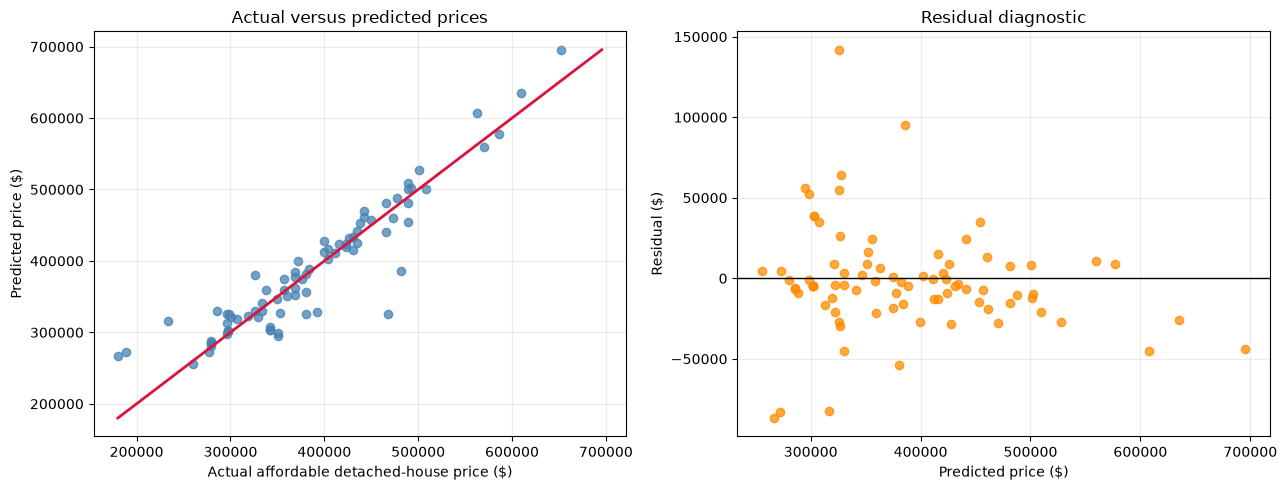

Interpretation: use the test metrics and residual pattern together; this cross-sectional model describes municipality-level relationships, not causal effects or time-series forecasts.


In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Actual-versus-predicted values show calibration and large outliers.
axes[0].scatter(y_test, y_pred, alpha=0.75, color="steelblue")
line_min = min(y_test.min(), y_pred.min())
line_max = max(y_test.max(), y_pred.max())
axes[0].plot([line_min, line_max], [line_min, line_max], color="crimson", linewidth=2)
axes[0].set_xlabel("Actual affordable detached-house price ($)")
axes[0].set_ylabel("Predicted price ($)")
axes[0].set_title("Actual versus predicted prices")
axes[0].grid(alpha=0.25)

residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.75, color="darkorange")
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_xlabel("Predicted price ($)")
axes[1].set_ylabel("Residual ($)")
axes[1].set_title("Residual diagnostic")
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

print("Interpretation: use the test metrics and residual pattern together; this cross-sectional model describes municipality-level relationships, not causal effects or time-series forecasts.")